# SHAP Explainability Analysis

## Objective
Explain the selected credit risk model using SHAP values and identify key drivers of predicted default risk.

## Setup

## Load and Clean Data

## Train Final Model

## Generate SHAP Values

## Global Feature Importance

## SHAP Summary Plot

## Local Explanation for Selected Borrowers

## Key Findings

## Model Risk Notes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

In [3]:
df = pd.read_csv("/content/cs-training.csv")
df = df.rename(columns={"Unnamed: 0": "customer_id"})

target = "SeriousDlqin2yrs"

df.loc[df["age"] == 0, "age"] = np.nan

delinquency_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for column in delinquency_columns:
    df[column] = df[column].replace([96, 98], np.nan)

X = df.drop(columns=["customer_id", target])
y = df[target].astype(int)

切分数据

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

训练模型

In [5]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42,
    )),
])

model.fit(X_train, y_train)

test_probability = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, test_probability))
print("Average Precision:", average_precision_score(y_test, test_probability))

ROC-AUC: 0.8681036023978276
Average Precision: 0.4083433160253769


SHAP解释处理后的特征

In [6]:
imputer = model.named_steps["imputer"]
classifier = model.named_steps["classifier"]

X_train_processed = imputer.transform(X_train)
X_test_processed = imputer.transform(X_test)

feature_names = list(X.columns) + [
    f"{feature}_missing_indicator"
    for feature in X.columns[imputer.indicator_.features_]
]

X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index,
)

In [9]:
X_shap_sample = X_test_shap.sample(n=1000, random_state=42)

explainer = shap.Explainer(classifier, X_shap_sample)
shap_values = explainer(X_shap_sample, check_additivity=False)

全局重要性表

In [10]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

importance_table = pd.DataFrame({
    "feature": feature_names,
    "mean_absolute_shap_value": mean_abs_shap,
}).sort_values("mean_absolute_shap_value", ascending=False)

importance_table.head(15)

,feature,mean_absolute_shap_value
0,RevolvingUtilizationOfUnsecuredLines,0.610007
2,NumberOfTime30-59DaysPastDueNotWorse,0.343317
1,age,0.247456
6,NumberOfTimes90DaysLate,0.180503
5,NumberOfOpenCreditLinesAndLoans,0.137966
8,NumberOfTime60-89DaysPastDueNotWorse,0.113271
3,DebtRatio,0.108778
4,MonthlyIncome,0.084432
7,NumberRealEstateLoansOrLines,0.071575
12,MonthlyIncome_missing_indicator,0.043129


画feature importance

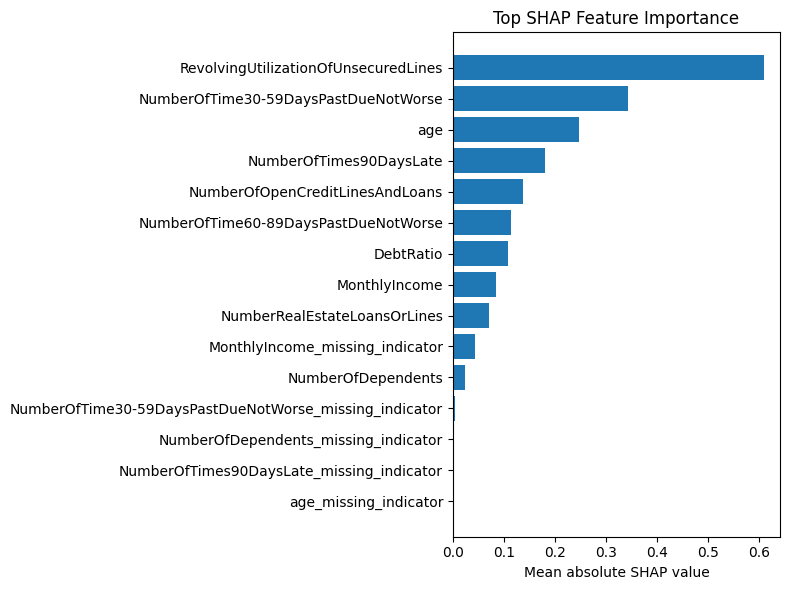

In [11]:
top_features = importance_table.head(15).sort_values("mean_absolute_shap_value")

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"],
    top_features["mean_absolute_shap_value"],
)
plt.xlabel("Mean absolute SHAP value")
plt.title("Top SHAP Feature Importance")
plt.tight_layout()
plt.show()

SHAP summary plot

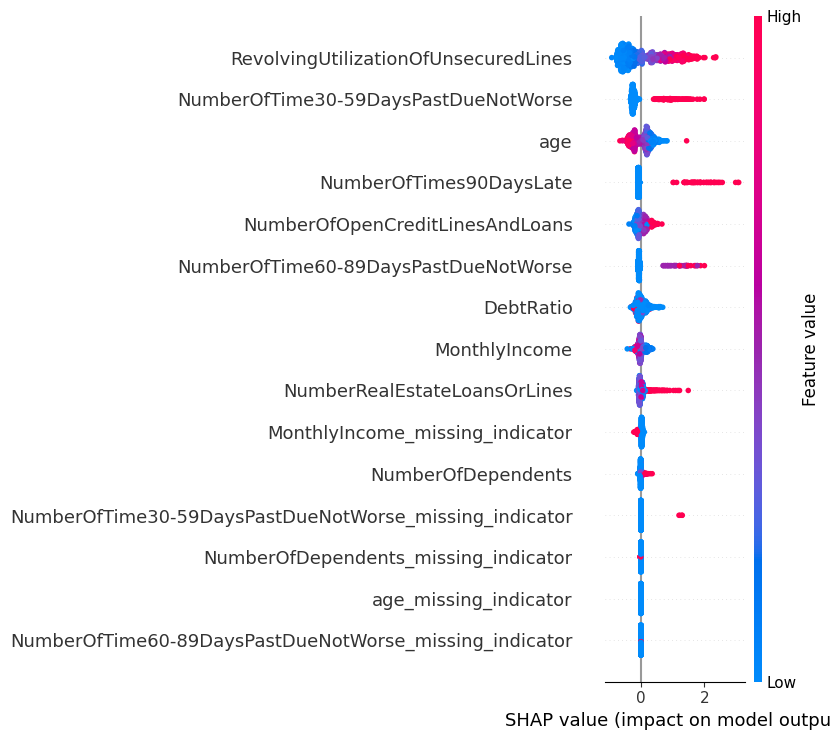

In [14]:
shap.summary_plot(
    shap_values.values,
    X_shap_sample,
    feature_names=feature_names,
    max_display=15,
)

局部解释：选择一个最高风险客户

In [17]:
X_shap_sample = X_test_shap.sample(n=1000, random_state=42)

explainer = shap.Explainer(classifier, X_shap_sample)
shap_values = explainer(X_shap_sample, check_additivity=False)

sample_probability = classifier.predict_proba(X_shap_sample)[:, 1]

local_index = np.argmax(sample_probability)

print("Selected sample position:", local_index)
print("Original borrower index:", X_shap_sample.index[local_index])
print("Predicted default probability:", sample_probability[local_index])

Selected sample position: 224
Original borrower index: 107351
Predicted default probability: 0.7637926538345361


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


Waterfall plot：

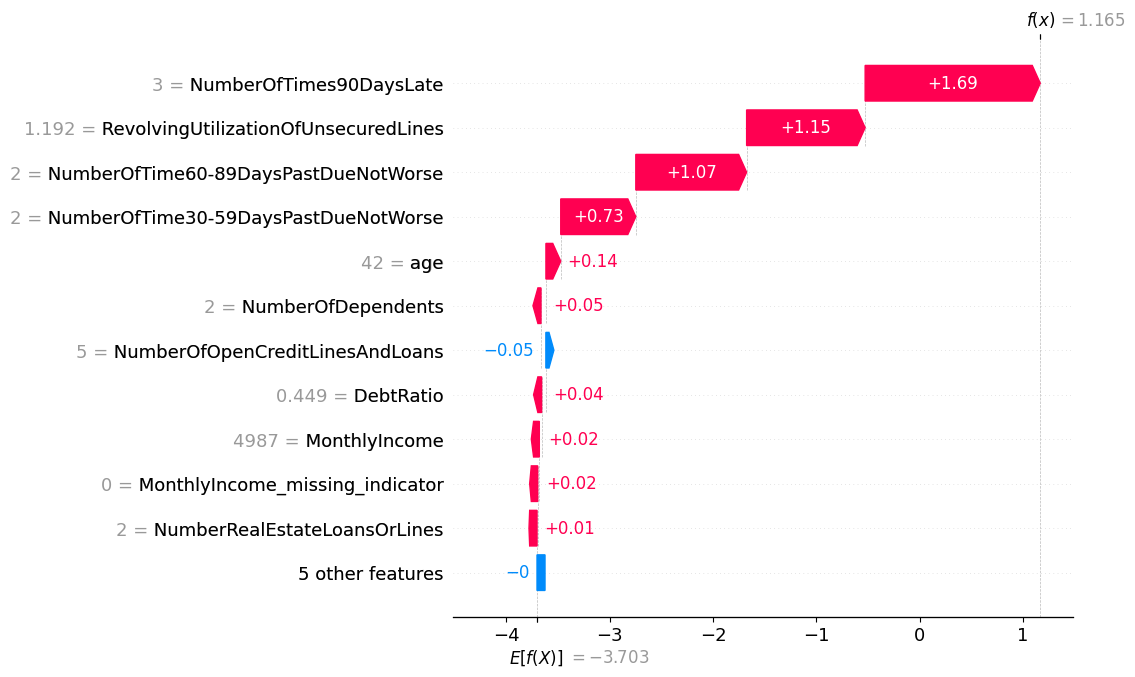

In [18]:
shap.plots.waterfall(
    shap_values[local_index],
    max_display=12
)

## Key Findings

- Historical delinquency variables are expected to be among the strongest drivers of predicted default risk.
- Revolving utilization and debt burden are expected to contribute meaningfully to risk ranking.
- Missing income indicators may carry predictive information and should be monitored carefully.
- SHAP results should be reviewed together with calibration, threshold performance, and portfolio stability metrics.

## Model Risk Notes

- SHAP values explain model behavior, not causal relationships.
- Correlated credit variables may share or shift attribution.
- Explanations should be used as model validation evidence, not as the only basis for credit decisions.